In [11]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import cohen_kappa_score, f1_score, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os, math

# ── Paths ──
AR_PATH = "../data/part2/arkansas_integrated.csv"
CA_PATH = "../data/part2/california_integrated.csv"
SAVE_DIR = "../data/part2/ablation"
os.makedirs(SAVE_DIR, exist_ok=True)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

ark_final = pd.read_csv(AR_PATH)
cal_final  = pd.read_csv(CA_PATH)
print(f"Arkansas columns: {len(ark_final.columns)} | rows: {len(ark_final)}")
print(f"California columns: {len(cal_final.columns)} | rows: {len(cal_final)}")

Device: cuda
Arkansas columns: 513 | rows: 10000
California columns: 513 | rows: 10000


In [12]:
print([c for c in ark_final.columns if c in ['label','target_label','crop_class']])
print([c for c in ark_final.columns if c.startswith('mask_')][:5])

['target_label']
['mask_0', 'mask_1', 'mask_2', 'mask_3', 'mask_4']


In [13]:
# ── Sentinel-2: 10 spectral bands × 36 time steps ──
S2_COLS = [col for col in ark_final.columns
           if col.startswith(('B2_','B3_','B4_','B5_','B6_',
                              'B7_','B8_','B8A_','B11_','B12_'))]

# ── Climate: 3 chosen from 7 ERA5 variables ──
# Justification:
#   temp   → captures phenological heat accumulation (GDD), key driver
#             of crop development timing (Allen et al., FAO 1998)
#   precip → water availability directly controls crop stress and
#             growing season length (Lobell & Burke 2010)
#   dew    → proxy for humidity/VPD; affects evapotranspiration and
#             disease pressure, improves discrimination of irrigated
#             vs rainfed crops (Rustowicz et al. 2019)
CLIMATE_COLS = [col for col in ark_final.columns
                if col.startswith(('temp_','precip_','dew_'))]

# ── Soil: 3 attributes (static per pixel) ──
# carbon (organic carbon) → soil fertility proxy
# ph     → soil acidity, constrains which crops can grow
# texture → drainage + water-holding capacity
SOIL_COLS = ['carbon', 'ph', 'texture']

# ── Topography: 2 attributes (static per pixel) ──
# elevation → altitude determines temperature regime + frost risk
# landforms → terrain position (ridge/valley/slope) affects drainage
TOPO_COLS = ['elevation', 'landforms']

# Mask columns (36 time steps)
MASK_COLS = [f'mask_{i}' for i in range(36)]

print(f"S2 cols:      {len(S2_COLS)}  (10 bands × 36 steps)")
print(f"Climate cols: {len(CLIMATE_COLS)}  (3 vars × 36 steps)")
print(f"Soil cols:    {len(SOIL_COLS)}")
print(f"Topo cols:    {len(TOPO_COLS)}")
print(f"Mask cols:    {len(MASK_COLS)}")

S2 cols:      360  (10 bands × 36 steps)
Climate cols: 108  (3 vars × 36 steps)
Soil cols:    3
Topo cols:    2
Mask cols:    36


# cell 3

In [14]:
# cell 3 - UPDATED with proper normalization
def load_config(df, config_name):
    """
    Returns X [N, 36, C], mask [N, 36], labels [N]
    with proper normalization for each group of features.
    """
    N = len(df)

    # ── Mask ──
    if all(c in df.columns for c in MASK_COLS):
        mask = df[MASK_COLS].values.astype(np.float32)
    else:
        s2_vals = df[S2_COLS].values.reshape(N, 36, 10)
        mask = (s2_vals.sum(axis=2) != 0).astype(np.float32)

    # ── Sentinel-2 (already normalized in Part 1) ──
    X_s2 = df[S2_COLS].values.reshape(N, 36, 10).astype(np.float32)

    if config_name == 's2_only':
        X = X_s2

    elif config_name == 's2_climate':
        X_clim = df[CLIMATE_COLS].values.reshape(N, 36, 3).astype(np.float32)
        # Normalize each climate variable independently
        for i in range(3):
            vmax = X_clim[:,:,i].max()
            if vmax > 0:
                X_clim[:,:,i] = X_clim[:,:,i] / vmax
        X = np.concatenate([X_s2, X_clim], axis=2)

    elif config_name == 's2_soil':
        X_soil = df[SOIL_COLS].fillna(0).values.astype(np.float32)
        # Min-Max normalization per feature
        X_soil = (X_soil - X_soil.min(axis=0)) / (X_soil.max(axis=0) - X_soil.min(axis=0) + 1e-8)
        X_soil_t = np.repeat(X_soil[:, np.newaxis, :], 36, axis=1)
        X = np.concatenate([X_s2, X_soil_t], axis=2)

    elif config_name == 's2_topo':
        X_topo = df[TOPO_COLS].fillna(0).values.astype(np.float32)
        X_topo = (X_topo - X_topo.min(axis=0)) / (X_topo.max(axis=0) - X_topo.min(axis=0) + 1e-8)
        X_topo_t = np.repeat(X_topo[:, np.newaxis, :], 36, axis=1)
        X = np.concatenate([X_s2, X_topo_t], axis=2)

    elif config_name == 's2_all':
        # Climate
        X_clim = df[CLIMATE_COLS].values.reshape(N, 36, 3).astype(np.float32)
        for i in range(3):
            vmax = X_clim[:,:,i].max()
            if vmax > 0:
                X_clim[:,:,i] = X_clim[:,:,i] / vmax
        # Soil
        X_soil = df[SOIL_COLS].fillna(0).values.astype(np.float32)
        X_soil = (X_soil - X_soil.min(axis=0)) / (X_soil.max(axis=0) - X_soil.min(axis=0) + 1e-8)
        X_soil_t = np.repeat(X_soil[:, np.newaxis, :], 36, axis=1)
        # Topography
        X_topo = df[TOPO_COLS].fillna(0).values.astype(np.float32)
        X_topo = (X_topo - X_topo.min(axis=0)) / (X_topo.max(axis=0) - X_topo.min(axis=0) + 1e-8)
        X_topo_t = np.repeat(X_topo[:, np.newaxis, :], 36, axis=1)

        X = np.concatenate([X_s2, X_clim, X_soil_t, X_topo_t], axis=2)

    # ── Labels ──
    label_col = next((c for c in ['label','target_label','crop_class','class'] 
                      if c in df.columns), None)
    if label_col is None:
        raise ValueError("No label column found!")
    labels = df[label_col].values.astype(np.int64)

    print(f"  [{config_name}] X: {X.shape} | mask: {mask.shape} | labels: {labels.shape}")
    return X, mask, labels

# cell 4

In [15]:
# ── Label remapping ──
AR_REMAP  = {5: 0, 3: 1, 1: 2, 2: 3}   # rest → 4 Others
AR_CLASSES = ['Soybeans','Rice','Corn','Cotton','Others']

CA_REMAP  = {69: 0, 3: 1, 36: 2, 75: 3, 204: 4}  # rest → 5 Others
CA_CLASSES = ['Grapes','Rice','Alfalfa','Almonds','Pistachios','Others']

# All grape variety codes for California
GRAPE_CODES = set(range(213, 255)) | {254}
for code in GRAPE_CODES:
    CA_REMAP[code] = 0


def remap_labels(labels, remap, n_classes):
    return np.array([remap.get(int(l), n_classes - 1) for l in labels])


def split_paper(labels, n_classes, n_train=240, n_val=60, seed=42):
    """300 samples/class → 240 train + 60 val, rest = test (paper Table 2)"""
    rng = np.random.RandomState(seed)
    tr, va, te = [], [], []
    for c in range(n_classes):
        idx = np.where(labels == c)[0]
        rng.shuffle(idx)
        if len(idx) >= n_train + n_val:
            tr.extend(idx[:n_train])
            va.extend(idx[n_train:n_train+n_val])
            te.extend(idx[n_train+n_val:])
        elif len(idx) >= n_train:
            tr.extend(idx[:n_train])
            va.extend(idx[n_train:])
        else:
            tr.extend(idx)
    return np.array(tr), np.array(va), np.array(te)


print("Splits ready.")

Splits ready.


# cell 5

In [16]:
import math
import torch
import torch.nn as nn

# ─────────────────────────────────────────────────────
# ECA — Efficient Channel Attention
# ─────────────────────────────────────────────────────
class ECA(nn.Module):
    def __init__(self, kernel_size=3):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.conv     = nn.Conv1d(1, 1, kernel_size=kernel_size, 
                                  padding=kernel_size//2, bias=False)
        self.sigmoid  = nn.Sigmoid()

    def forward(self, x):
        # x: [B, T, C]
        y = x.transpose(1, 2)    # [B, C, T]
        y = self.avg_pool(y)     # [B, C, 1]
        y = y.transpose(1, 2)    # [B, 1, C]
        y = self.conv(y)         # [B, 1, C]
        y = self.sigmoid(y)      # [B, 1, C]
        return x * y             # [B, T, C]

# ─────────────────────────────────────────────────────
# ALPE — Attention-based Learnable Positional Encoding
# ─────────────────────────────────────────────────────
class ALPE(nn.Module):
    def __init__(self, seq_len, d_model):
        super().__init__()
        self.conv1d = nn.Conv1d(d_model, d_model, kernel_size=3, padding=1, bias=False)
        self.eca    = ECA(kernel_size=3)

        pe = torch.zeros(seq_len, d_model)
        position = torch.arange(seq_len).float().unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term[:pe[:, 1::2].shape[1]])
        self.register_buffer('pe', pe)

    def forward(self, x, mask):
        B = x.shape[0]
        pe = self.pe.unsqueeze(0).expand(B, -1, -1)
        mask_exp = mask.unsqueeze(-1).float()
        pe_masked = pe * mask_exp
        
        pe_conv = self.conv1d(pe_masked.transpose(1, 2)).transpose(1, 2)
        pe_out = self.eca(pe_conv)
        return x + pe_out

# ─────────────────────────────────────────────────────
# Transformer Sub-module (Figure 4)
# ─────────────────────────────────────────────────────
class TransformerSubModule(nn.Module):
    def __init__(self, d_model, n_head, use_alpe=False, seq_len=None, dropout=0.15, ff_mult=4):
        super().__init__()
        self.use_alpe = use_alpe
        if use_alpe:
            self.alpe = ALPE(seq_len, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_head,
            dim_feedforward=d_model * ff_mult,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        if self.use_alpe and mask is not None:
            x = self.alpe(x, mask)
        x = self.transformer(x)
        x = self.dropout(x)
        return x

# ─────────────────────────────────────────────────────
# CNN Sub-module (Figure 6)
# ─────────────────────────────────────────────────────
class CNNSubModule(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, expansion=2):
        super().__init__()
        pad = kernel_size // 2
        hid_ch = in_ch * expansion 
        
        self.conv1 = nn.Conv1d(in_ch, hid_ch, kernel_size, padding=pad, bias=False)
        self.bn1 = nn.BatchNorm1d(hid_ch)
        self.conv2 = nn.Conv1d(hid_ch, out_ch, kernel_size, padding=pad, bias=False)
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.relu = nn.ReLU()
        self.skip = (nn.Conv1d(in_ch, out_ch, 1, bias=False) if in_ch != out_ch else nn.Identity())

    def forward(self, x):
        x = x.transpose(1, 2) 
        residual = self.skip(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.relu(out + residual)
        return out.transpose(1, 2)

# ─────────────────────────────────────────────────────
# CTFusion Module (Figure 3)
# ─────────────────────────────────────────────────────
class CTFusion(nn.Module):
    def __init__(self, in_ch, n_head, kernel_size=3, use_alpe=False, seq_len=None, dropout=0.15):
        super().__init__()
        # CNN and Transformer both process 'in_ch' and produce 'in_ch'
        self.cnn = CNNSubModule(in_ch, in_ch, kernel_size, expansion=2)
        self.transformer = TransformerSubModule(
            in_ch, n_head, use_alpe=use_alpe, seq_len=seq_len, dropout=dropout
        )
        # Pooling reduces sequence length, concatenation doubles channel depth
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(0.1)

    def forward(self, x, mask=None):
        cnn_out = self.cnn(x)  
        trans_out = self.transformer(x, mask)  
        fused = torch.cat([cnn_out, trans_out], dim=-1)  # Channels: in_ch -> 2*in_ch
        fused = self.dropout(fused)
        fused = self.pool(fused.transpose(1, 2)).transpose(1, 2)  
        return fused

# ─────────────────────────────────────────────────────
# MCTNet — Full Architecture with Flexible Input
# ─────────────────────────────────────────────────────
class MCTNet(nn.Module):
    def __init__(self, in_channels, seq_len=36, n_classes=5, 
                 n_stage=3, d_model=16, kernel_size=3, dropout=0.15):
        super().__init__()

        # THE BRIDGE: Maps any covariate count to a fixed internal d_model
        self.input_proj = nn.Linear(in_channels, d_model)

        self.stages = nn.ModuleList()
        cur_ch = d_model
        cur_seq = seq_len

        for i in range(n_stage):
            # n_head must divide cur_ch
            n_head = 4 if cur_ch % 4 == 0 else 2
            
            self.stages.append(
                CTFusion(
                    in_ch=cur_ch,
                    n_head=n_head,
                    kernel_size=kernel_size,
                    use_alpe=(i == 0),  
                    seq_len=cur_seq,
                    dropout=dropout
                )
            )
            cur_ch = cur_ch * 2  # Each CTFusion doubles channels via concat
            cur_seq = cur_seq // 2

        self.classifier_dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(cur_ch, n_classes)

    def forward(self, x, mask=None):
        # Initial projection to standardized d_model
        x = self.input_proj(x)
        
        for i, stage in enumerate(self.stages):
            # Only apply ALPE/masking to the first stage
            m = mask if i == 0 else None
            x = stage(x, m)
            
        # Global Max Pooling across the time dimension
        x = x.max(dim=1).values
        x = self.classifier_dropout(x)
        return self.classifier(x)

# ─────────────────────────────────────────────────────
# Final Verification
# ─────────────────────────────────────────────────────
print("Verifying MCTNet with varying input configurations:")
for cfg, ic in [('s2_only',10), ('s2_climate',13), ('s2_all',18)]:
    model = MCTNet(in_channels=ic, d_model=16) # Standardized internal capacity
    x = torch.randn(4, 36, ic)
    mask = torch.ones(4, 36)
    out = model(x, mask)
    params = sum(p.numel() for p in model.parameters())
    print(f"  [{cfg:^10}] Input Channels: {ic} -> Output: {out.shape} | Params: {params:,}")

Verifying MCTNet with varying input configurations:
  [ s2_only  ] Input Channels: 10 -> Output: torch.Size([4, 5]) | Params: 132,744
  [s2_climate] Input Channels: 13 -> Output: torch.Size([4, 5]) | Params: 132,792
  [  s2_all  ] Input Channels: 18 -> Output: torch.Size([4, 5]) | Params: 132,872


# cell 6

In [17]:
# cell 6 - Updated with better per-state weight_decay
class CropDS(Dataset):
    def __init__(self, X, mask, y):
        self.X    = torch.tensor(X,    dtype=torch.float32)
        self.mask = torch.tensor(mask, dtype=torch.float32)
        self.y    = torch.tensor(y,    dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.mask[i], self.y[i]


def train_one_epoch(model, loader, opt, crit, dev):
    model.train()
    loss_sum, correct, total = 0, 0, 0
    for X, mask, y in loader:
        X, mask, y = X.to(dev), mask.to(dev), y.to(dev)
        opt.zero_grad()
        out  = model(X, mask)
        loss = crit(out, y)
        loss.backward()
        opt.step()
        loss_sum += loss.item() * len(y)
        correct  += (out.argmax(1) == y).sum().item()
        total    += len(y)
    return loss_sum/total, correct/total


def evaluate(model, loader, crit, dev):
    model.eval()
    loss_sum = 0
    preds, truths = [], []
    with torch.no_grad():
        for X, mask, y in loader:
            X, mask, y = X.to(dev), mask.to(dev), y.to(dev)
            out = model(X, mask)
            loss_sum += crit(out, y).item() * len(y)
            preds.extend(out.argmax(1).cpu().numpy())
            truths.extend(y.cpu().numpy())
    n     = len(truths)
    oa    = accuracy_score(truths, preds)
    kappa = cohen_kappa_score(truths, preds)
    f1    = f1_score(truths, preds, average='macro', zero_division=0)
    return loss_sum/n, oa, kappa, f1, np.array(preds), np.array(truths)


def run_config(cfg_name, X, mask, labels, class_names,
               epochs=80, batch=32, lr=0.0005, d_model=16, 
               patience=12, weight_decay=None):
    """Per-state friendly version with d_model=16 and tuned per-state weight_decay"""
    n_classes = len(class_names)
    
    # Per-state regularization (tuned based on latest runs)
    if weight_decay is None:
        if n_classes == 5:        # Arkansas
            weight_decay = 2e-5   # worked well
        else:                     # California
            weight_decay = 3e-5   # reduced from 5e-5 to avoid over-regularization
    
    remap = AR_REMAP if n_classes == 5 else CA_REMAP
    y = remap_labels(labels, remap, n_classes)

    tr_idx, va_idx, te_idx = split_paper(y, n_classes)

    tr_ds = CropDS(X[tr_idx], mask[tr_idx], y[tr_idx])
    va_ds = CropDS(X[va_idx], mask[va_idx], y[va_idx])
    te_ds = CropDS(X[te_idx], mask[te_idx], y[te_idx])

    tr_loader = DataLoader(tr_ds, batch_size=batch, shuffle=True,  num_workers=0)
    va_loader = DataLoader(va_ds, batch_size=batch, shuffle=False, num_workers=0)
    te_loader = DataLoader(te_ds, batch_size=256,  shuffle=False, num_workers=0)

    model = MCTNet(in_channels=X.shape[2], seq_len=36,
                   n_classes=n_classes, d_model=d_model).to(device)
    
    opt  = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    crit = nn.CrossEntropyLoss()

    best_kappa, best_state = -1, None
    best_epoch = 0
    patience_counter = 0
    history = []

    print(f"\n  Training [{cfg_name}] | in_ch={X.shape[2]} | "
          f"params={sum(p.numel() for p in model.parameters()):,} | wd={weight_decay}")

    for ep in range(1, epochs+1):
        tr_loss, tr_oa = train_one_epoch(model, tr_loader, opt, crit, device)
        va_loss, va_oa, va_kappa, va_f1, _, _ = evaluate(model, va_loader, crit, device)
        
        history.append({'epoch':ep,'tr_loss':tr_loss,'tr_oa':tr_oa,
                         'va_loss':va_loss,'va_oa':va_oa,
                         'va_kappa':va_kappa,'va_f1':va_f1})

        if va_kappa > best_kappa:
            best_kappa = va_kappa
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            best_epoch = ep
            patience_counter = 0
        else:
            patience_counter += 1

        if ep % 15 == 0:
            print(f"    Ep {ep:3d} | tr_oa:{tr_oa:.3f} | "
                  f"va_oa:{va_oa:.3f} kappa:{va_kappa:.3f} f1:{va_f1:.3f}")

        if patience_counter >= patience:
            print(f"    Early stopping at epoch {ep} (best at epoch {best_epoch})")
            break

    model.load_state_dict(best_state)
    _, te_oa, te_kappa, te_f1, preds, truths = evaluate(model, te_loader, crit, device)

    print(f"  → TEST  OA:{te_oa:.4f}  Kappa:{te_kappa:.4f}  F1:{te_f1:.4f} "
          f"(best val at ep {best_epoch})")

    torch.save(model.state_dict(),
               os.path.join(SAVE_DIR, f'mctnet_{cfg_name}.pth'))

    return {
        'config':   cfg_name,
        'oa':       te_oa,
        'kappa':    te_kappa,
        'f1':       te_f1,
        'history':  pd.DataFrame(history),
        'preds':    preds,
        'truths':   truths,
        'classes':  class_names,
        'best_epoch': best_epoch
    }


print("Functions ready (d_model=16 + tuned per-state weight_decay).")

Functions ready (d_model=16 + tuned per-state weight_decay).


# cell 7

In [18]:
CONFIGS = ['s2_only', 's2_climate', 's2_soil', 's2_topo', 's2_all']

print("="*60)
print("ARKANSAS ABLATION STUDY")
print("="*60)

ark_results = {}
for cfg in CONFIGS:
    X, mask, labels = load_config(ark_final, cfg)
    ark_results[cfg] = run_config(
        cfg, X, mask, labels, AR_CLASSES,
        epochs=60, batch=32, lr=0.0005, d_model=16,
        patience=12
        # weight_decay will be automatically set to 2e-5 for Arkansas
    )

print("\n=== ARKANSAS SUMMARY ===")
print(f"{'Config':<18} {'OA':>8} {'Kappa':>8} {'F1':>8}")
print("-"*46)
for cfg, r in ark_results.items():
    print(f"{cfg:<18} {r['oa']:>8.4f} {r['kappa']:>8.4f} {r['f1']:>8.4f}")

ARKANSAS ABLATION STUDY
  [s2_only] X: (10000, 36, 10) | mask: (10000, 36) | labels: (10000,)

  Training [s2_only] | in_ch=10 | params=132,744 | wd=2e-05
    Ep  15 | tr_oa:0.526 | va_oa:0.697 kappa:0.621 f1:0.700
    Ep  30 | tr_oa:0.779 | va_oa:0.870 kappa:0.838 f1:0.872
    Ep  45 | tr_oa:0.793 | va_oa:0.877 kappa:0.846 f1:0.877
    Early stopping at epoch 57 (best at epoch 45)
  → TEST  OA:0.8427  Kappa:0.7630  F1:0.8308 (best val at ep 45)
  [s2_climate] X: (10000, 36, 13) | mask: (10000, 36) | labels: (10000,)

  Training [s2_climate] | in_ch=13 | params=132,792 | wd=2e-05
    Ep  15 | tr_oa:0.675 | va_oa:0.710 kappa:0.637 f1:0.705
    Ep  30 | tr_oa:0.848 | va_oa:0.817 kappa:0.771 f1:0.820
    Early stopping at epoch 31 (best at epoch 19)
  → TEST  OA:0.8264  Kappa:0.7402  F1:0.7924 (best val at ep 19)
  [s2_soil] X: (10000, 36, 13) | mask: (10000, 36) | labels: (10000,)

  Training [s2_soil] | in_ch=13 | params=132,792 | wd=2e-05
    Ep  15 | tr_oa:0.674 | va_oa:0.747 kappa:0.

# cell 8

In [19]:
print("="*60)
print("CALIFORNIA ABLATION STUDY")
print("="*60)

cal_results = {}
for cfg in CONFIGS:
    X, mask, labels = load_config(cal_final, cfg)
    cal_results[cfg] = run_config(
        cfg, X, mask, labels, CA_CLASSES,
        epochs=90, batch=32, lr=0.0007, d_model=16,
        patience=12
        # weight_decay will be automatically set to 5e-5 for California
    )

print("\n=== CALIFORNIA SUMMARY ===")
print(f"{'Config':<18} {'OA':>8} {'Kappa':>8} {'F1':>8}")
print("-"*46)
for cfg, r in cal_results.items():
    print(f"{cfg:<18} {r['oa']:>8.4f} {r['kappa']:>8.4f} {r['f1']:>8.4f}")

CALIFORNIA ABLATION STUDY
  [s2_only] X: (10000, 36, 10) | mask: (10000, 36) | labels: (10000,)

  Training [s2_only] | in_ch=10 | params=132,873 | wd=3e-05
    Ep  15 | tr_oa:0.734 | va_oa:0.758 kappa:0.710 f1:0.748
    Ep  30 | tr_oa:0.815 | va_oa:0.825 kappa:0.790 f1:0.819
    Early stopping at epoch 40 (best at epoch 28)
  → TEST  OA:0.8824  Kappa:0.8450  F1:0.8435 (best val at ep 28)
  [s2_climate] X: (10000, 36, 13) | mask: (10000, 36) | labels: (10000,)

  Training [s2_climate] | in_ch=13 | params=132,921 | wd=3e-05
    Ep  15 | tr_oa:0.756 | va_oa:0.792 kappa:0.750 f1:0.783
    Ep  30 | tr_oa:0.805 | va_oa:0.831 kappa:0.797 f1:0.830
    Ep  45 | tr_oa:0.858 | va_oa:0.803 kappa:0.763 f1:0.789
    Ep  60 | tr_oa:0.872 | va_oa:0.861 kappa:0.833 f1:0.861
    Ep  75 | tr_oa:0.901 | va_oa:0.889 kappa:0.867 f1:0.886
    Ep  90 | tr_oa:0.914 | va_oa:0.872 kappa:0.847 f1:0.872
  → TEST  OA:0.9351  Kappa:0.9131  F1:0.9009 (best val at ep 87)
  [s2_soil] X: (10000, 36, 13) | mask: (10000,

# cell 9

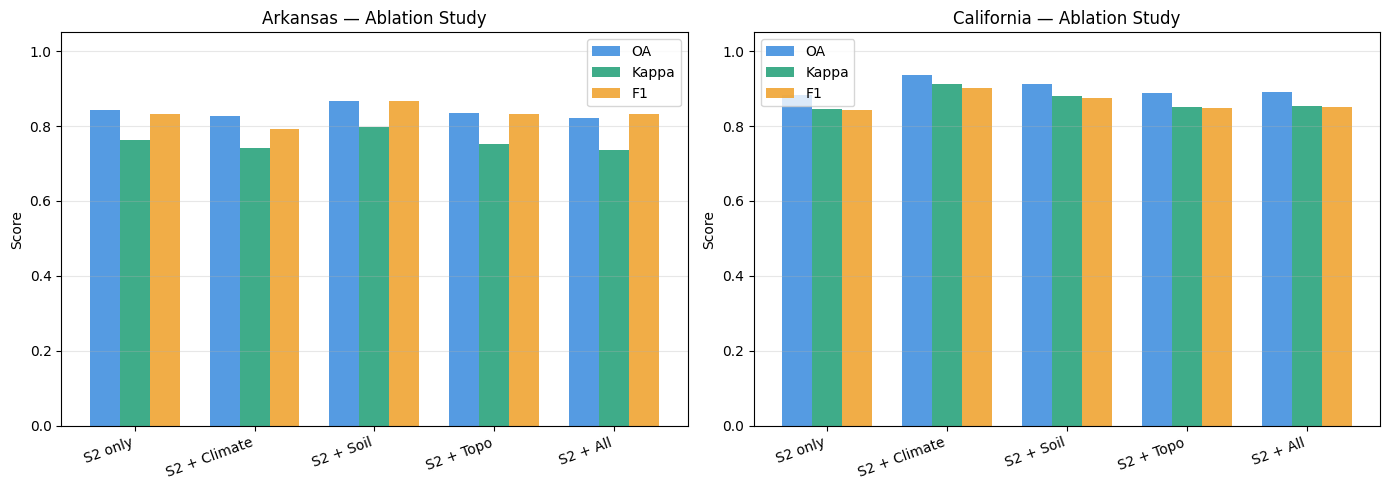

Saved: ablation_bar_comparison.png


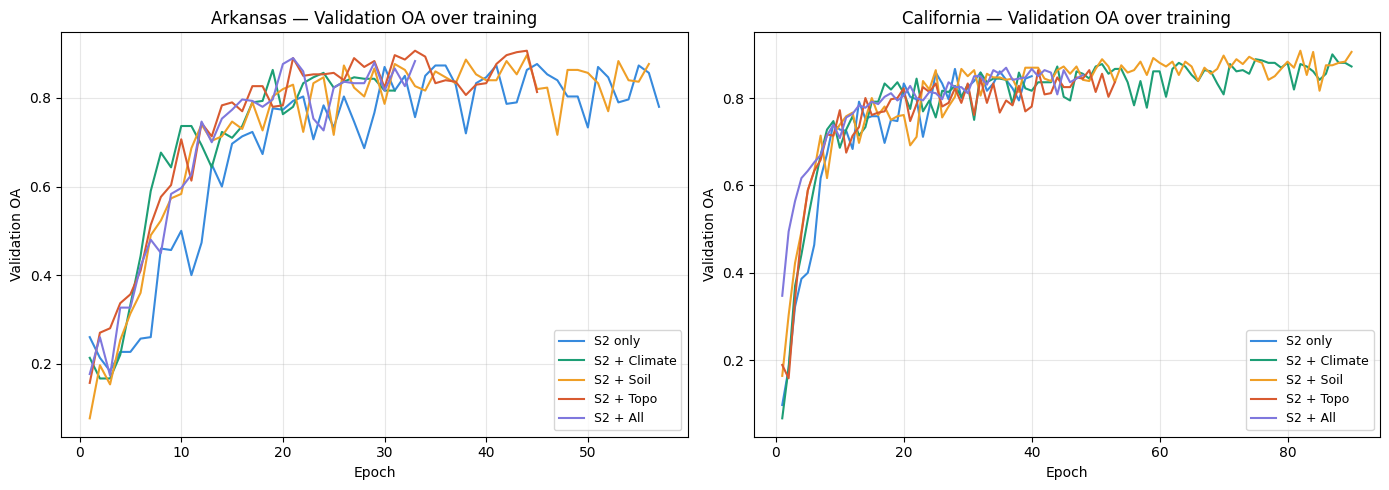

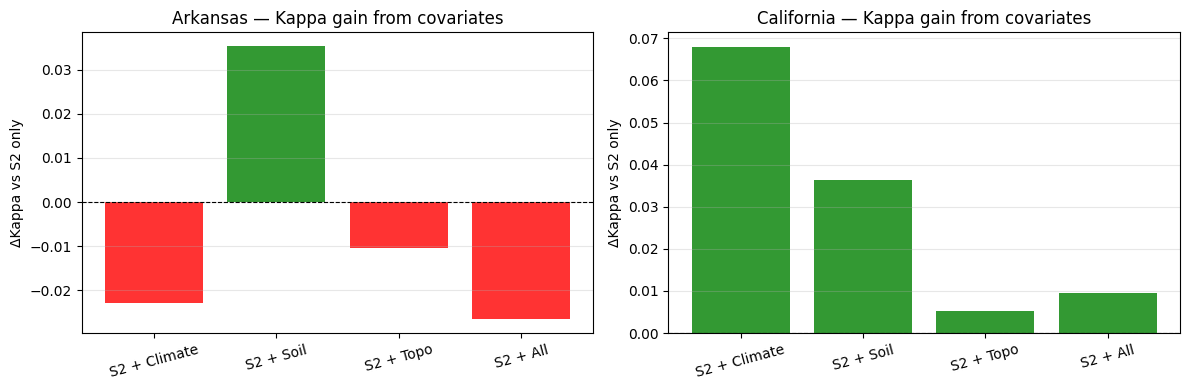

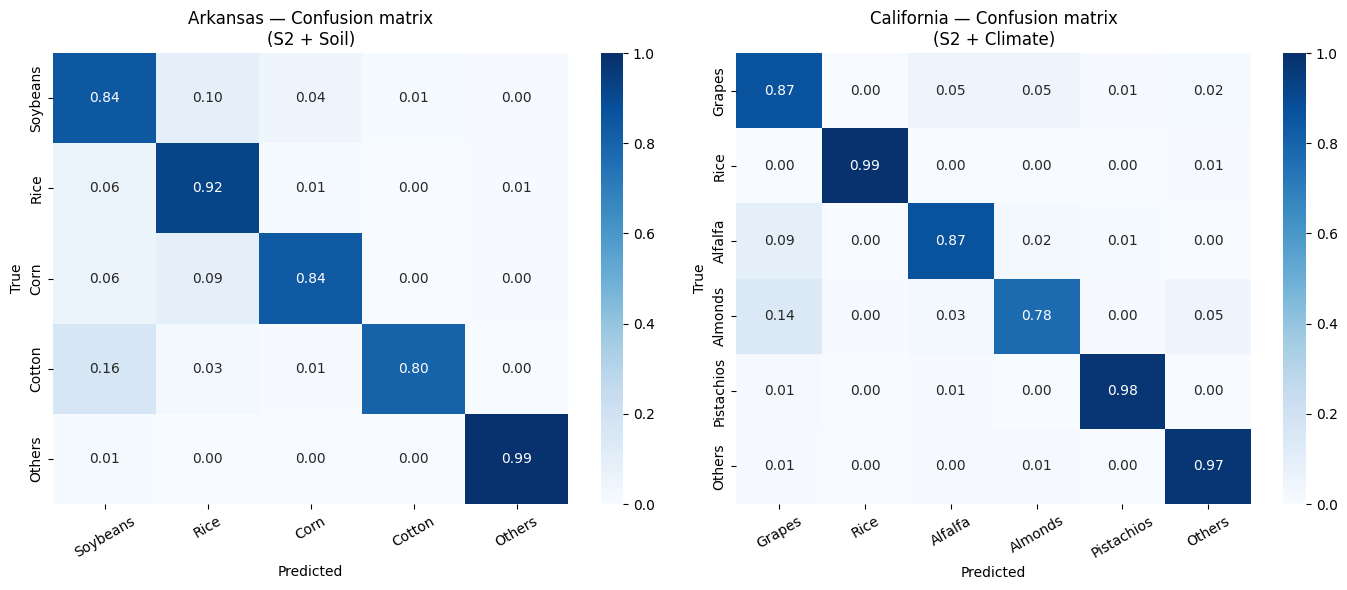

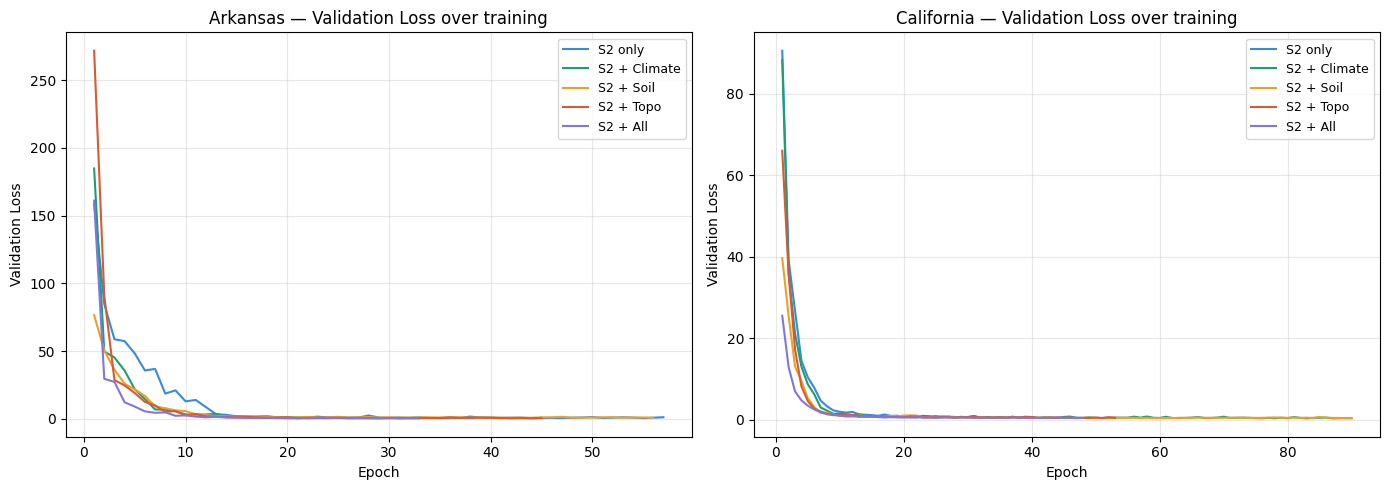

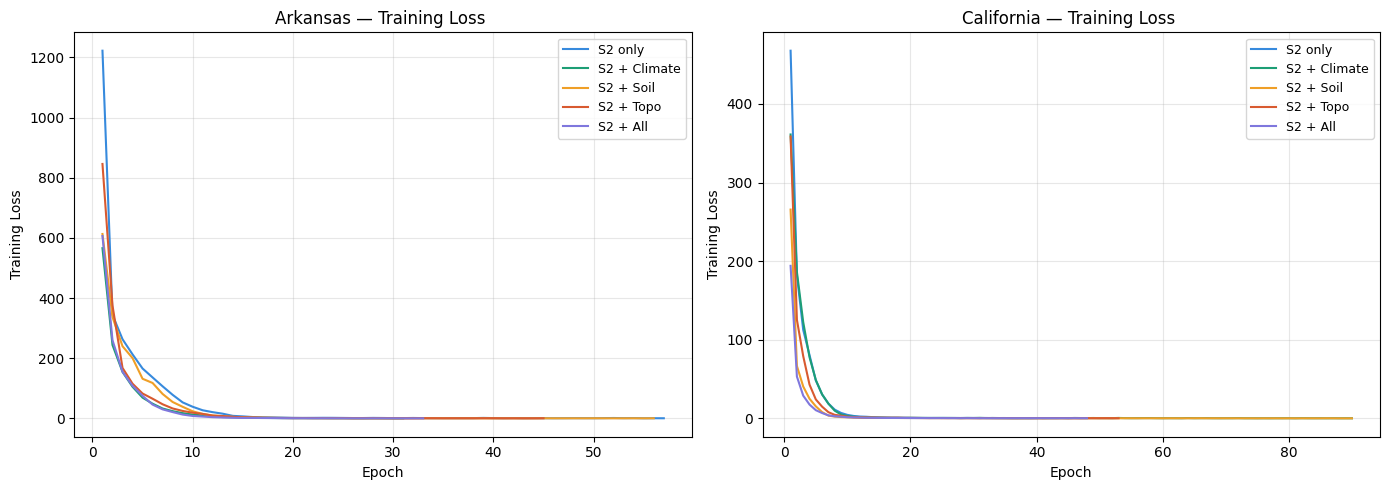


All plots saved! (including new Training Loss curves)


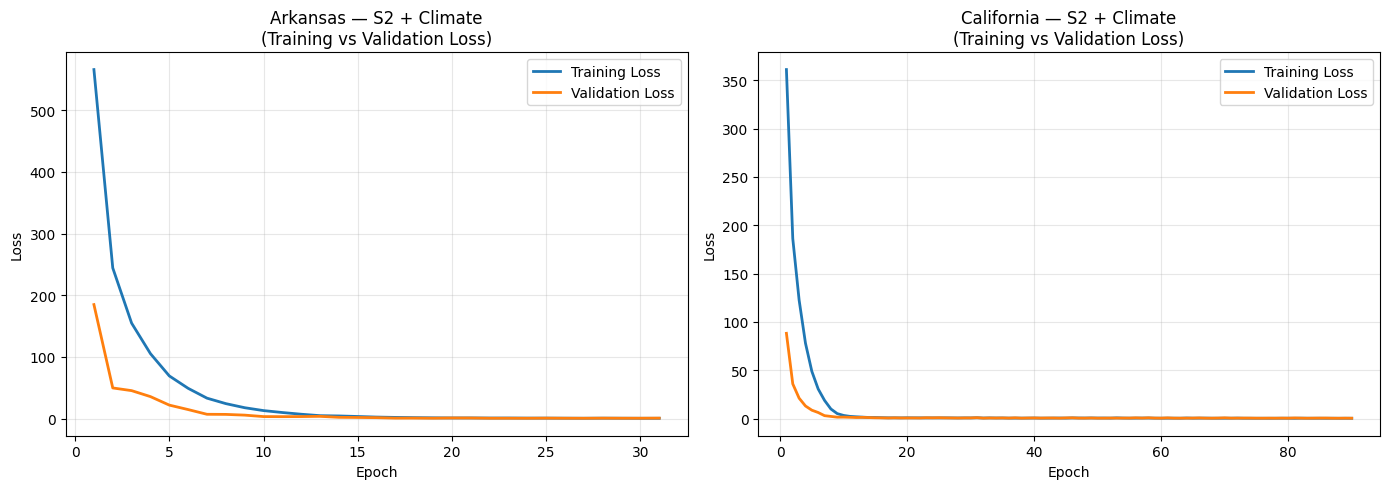

Saved: s2_climate_train_vs_val_loss.png  (Training vs Validation Loss for S2+Climate)


In [20]:
# cell 9 - UPDATED with separate Training Loss curve
CONFIG_LABELS = {
    's2_only':    'S2 only',
    's2_climate': 'S2 + Climate',
    's2_soil':    'S2 + Soil',
    's2_topo':    'S2 + Topo',
    's2_all':     'S2 + All'
}
COLORS = ['#378ADD','#1D9E75','#EF9F27','#D85A30','#7F77DD']

# ── Figure 1: Bar chart comparison (OA, Kappa, F1) ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, results, title in zip(axes, [ark_results, cal_results], ['Arkansas', 'California']):
    cfgs   = list(results.keys())
    labels = [CONFIG_LABELS[c] for c in cfgs]
    oa     = [results[c]['oa']    for c in cfgs]
    kappa  = [results[c]['kappa'] for c in cfgs]
    f1     = [results[c]['f1']    for c in cfgs]
    x = np.arange(len(cfgs))
    w = 0.25
    ax.bar(x - w, oa,    w, label='OA',    color='#378ADD', alpha=0.85)
    ax.bar(x,     kappa, w, label='Kappa', color='#1D9E75', alpha=0.85)
    ax.bar(x + w, f1,    w, label='F1',    color='#EF9F27', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=20, ha='right', fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Score')
    ax.set_title(f'{title} — Ablation Study')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'ablation_bar_comparison.png'), dpi=150)
plt.show()
print("Saved: ablation_bar_comparison.png")


# ── Figure 2: Validation OA curves ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, results, title in zip(axes, [ark_results, cal_results], ['Arkansas', 'California']):
    for cfg, color in zip(CONFIGS, COLORS):
        h = results[cfg]['history']
        ax.plot(h['epoch'], h['va_oa'], label=CONFIG_LABELS[cfg], color=color, linewidth=1.5)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Validation OA')
    ax.set_title(f'{title} — Validation OA over training')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'ablation_training_curves.png'), dpi=150)
plt.show()


# ── Figure 3: Kappa improvement over baseline ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, results, title in zip(axes, [ark_results, cal_results], ['Arkansas', 'California']):
    baseline = results['s2_only']['kappa']
    cfgs     = [c for c in CONFIGS if c != 's2_only']
    deltas   = [results[c]['kappa'] - baseline for c in cfgs]
    colors   = ['green' if d >= 0 else 'red' for d in deltas]
    ax.bar([CONFIG_LABELS[c] for c in cfgs], deltas, color=colors, alpha=0.8)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_ylabel('ΔKappa vs S2 only')
    ax.set_title(f'{title} — Kappa gain from covariates')
    ax.tick_params(axis='x', rotation=15)
    ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'ablation_kappa_delta.png'), dpi=150)
plt.show()


# ── Figure 4: Confusion matrices for best config ──
def best_config(results):
    return max(results, key=lambda c: results[c]['kappa'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, results, title, classes in zip(axes, [ark_results, cal_results], ['Arkansas', 'California'], [AR_CLASSES, CA_CLASSES]):
    best = best_config(results)
    preds  = results[best]['preds']
    truths = results[best]['truths']
    cm = confusion_matrix(truths, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=classes, yticklabels=classes, ax=ax,
                vmin=0, vmax=1)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'{title} — Confusion matrix\n({CONFIG_LABELS[best]})')
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'ablation_confusion_matrices.png'), dpi=150)
plt.show()


# ── Figure 5: Validation Loss curves ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, results, title in zip(axes, [ark_results, cal_results], ['Arkansas', 'California']):
    for cfg, color in zip(CONFIGS, COLORS):
        h = results[cfg]['history']
        ax.plot(h['epoch'], h['va_loss'], label=CONFIG_LABELS[cfg], color=color, linewidth=1.5)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Validation Loss')
    ax.set_title(f'{title} — Validation Loss over training')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'ablation_val_loss_curves.png'), dpi=150)
plt.show()


# ── Figure 6: Training Loss curves (NEW) ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, results, title in zip(axes, [ark_results, cal_results], ['Arkansas', 'California']):
    for cfg, color in zip(CONFIGS, COLORS):
        h = results[cfg]['history']
        ax.plot(h['epoch'], h['tr_loss'], label=CONFIG_LABELS[cfg], color=color, linewidth=1.5)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Training Loss')
    ax.set_title(f'{title} — Training Loss ')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'ablation_train_loss_curves.png'), dpi=150)
plt.show()

print("\nAll plots saved! (including new Training Loss curves)")

# ── NEW FIGURE: Training Loss vs Validation Loss for S2 + Climate only ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, results, title, cfg_name in zip(
    axes,
    [ark_results, cal_results],
    ['Arkansas', 'California'],
    ['s2_climate', 's2_climate']):

    h = results[cfg_name]['history']
    
    ax.plot(h['epoch'], h['tr_loss'], 
            label='Training Loss', color='#1f77b4', linewidth=2)
    ax.plot(h['epoch'], h['va_loss'], 
            label='Validation Loss', color='#ff7f0e', linewidth=2)
    
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title(f'{title} — S2 + Climate\n(Training vs Validation Loss)')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 's2_climate_train_vs_val_loss.png'), dpi=200)
plt.show()

print("Saved: s2_climate_train_vs_val_loss.png  (Training vs Validation Loss for S2+Climate)")

# cell 10

In [ ]:
print("\n" + "="*100)
print("FINAL ABLATION STUDY RESULTS")
print("="*100)

for state, results, classes in [
    ("Arkansas",   ark_results, AR_CLASSES),
    ("California", cal_results, CA_CLASSES)
]:
    # Set the baseline (Sentinel-2 only)
    base = results['s2_only']
    best_cfg = max(results, key=lambda c: results[c]['kappa'])

    print(f"\n{'─'*100}")
    print(f"{state}")
    print(f"{'─'*100}")
    # Header showing Metric and its Delta (Δ)
    print(f"  {'Configuration':<20} {'OA':>8} {'ΔOA':>8} {'Kappa':>8} {'ΔKap':>8} {'F1':>8} {'ΔF1':>8}")
    print(f"  {'─'*95}")
    
    for cfg in CONFIGS:
        r = results[cfg]
        
        # Calculate deltas for each metric
        d_oa  = r['oa'] - base['oa']
        d_kap = r['kappa'] - base['kappa']
        d_f1  = r['f1'] - base['f1']
        
        marker = ' ← best' if cfg == best_cfg else ''
        
        # Print metrics alongside their deltas (formatted with + sign for improvements)
        print(f"  {CONFIG_LABELS[cfg]:<20} "
              f"{r['oa']:>8.4f} {d_oa:>+8.4f} "
              f"{r['kappa']:>8.4f} {d_kap:>+8.4f} "
              f"{r['f1']:>8.4f} {d_f1:>+8.4f}{marker}")

    print(f"\n  Best configuration: {CONFIG_LABELS[best_cfg]}")
    print(f"  Overall Kappa improvement: {results[best_cfg]['kappa'] - base['kappa']:+.4f}")

# Save full results table including all deltas
rows = []
for state, results in [('Arkansas', ark_results), ('California', cal_results)]:
    base = results['s2_only']
    for cfg in CONFIGS:
        r = results[cfg]
        rows.append({
            'State': state, 
            'Config': CONFIG_LABELS[cfg],
            'OA': round(r['oa'], 4), 
            'Delta_OA': round(r['oa'] - base['oa'], 4),
            'Kappa': round(r['kappa'], 4), 
            'Delta_Kappa': round(r['kappa'] - base['kappa'], 4),
            'F1': round(r['f1'], 4),
            'Delta_F1': round(r['f1'] - base['f1'], 4)
        })

df_summary = pd.DataFrame(rows)
df_summary.to_csv(os.path.join(SAVE_DIR, '../data/part2/ablation_results.csv'), index=False)
print(f"\nResults saved to ablation_results.csv")


FINAL ABLATION STUDY RESULTS

────────────────────────────────────────────────────────────────────────────────────────────────────
Arkansas
────────────────────────────────────────────────────────────────────────────────────────────────────
  Configuration              OA      ΔOA    Kappa     ΔKap       F1      ΔF1
  ───────────────────────────────────────────────────────────────────────────────────────────────
  S2 only                0.8427  +0.0000   0.7630  +0.0000   0.8308  +0.0000
  S2 + Climate           0.8264  -0.0164   0.7402  -0.0228   0.7924  -0.0384
  S2 + Soil              0.8668  +0.0241   0.7983  +0.0354   0.8673  +0.0365 ← best
  S2 + Topo              0.8341  -0.0086   0.7525  -0.0104   0.8323  +0.0015
  S2 + All               0.8218  -0.0209   0.7364  -0.0266   0.8321  +0.0013

  Best configuration: S2 + Soil
  Overall Kappa improvement: +0.0354

────────────────────────────────────────────────────────────────────────────────────────────────────
California
────────